In [2]:
import numpy as np
import pandas as pd
import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 


In [3]:
df = pd.read_csv('../data/Amazon_employee_access.csv')

In [4]:
from sklearn.metrics import accuracy_score, precision_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') 
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision,confusion_mx

In [5]:
X = df.drop(columns=["target"])  
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression()
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)

In [7]:
logreg_accuracy, logreg_precision,logreg_confusion_mx = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
nb_accuracy, nb_precision,nb_confusion_mx = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
rf_accuracy, rf_precision,rf_confusion_mx = evaluate_classifier(rf, X_train, y_train, X_test, y_test)

print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}, Precision: {logreg_precision:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}, Precision: {nb_precision:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}\n\n")

print(f"Logistic Regression Confusion Matrix:\n{logreg_confusion_mx}")
print(f"Naive Bayes Confusion Matrix:\n{nb_confusion_mx}")
print(f"Random Forest Confusion Matrix:\n{rf_confusion_mx}")

Logistic Regression Accuracy: 0.9437, Precision: 0.9437
Naive Bayes Accuracy: 0.9135, Precision: 0.9446
Random Forest Accuracy: 0.9504, Precision: 0.9578


Logistic Regression Confusion Matrix:
[[   0  369]
 [   0 6185]]
Naive Bayes Confusion Matrix:
[[  19  350]
 [ 217 5968]]
Random Forest Confusion Matrix:
[[  99  270]
 [  55 6130]]


In [8]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x000,x001,x002,x003,x004,x005,x006,x007,x008,x009,...,x006*x007,x007**3/x005,x002*Abs(x004),exp(x008)/x004,x001**3*Abs(x000),x007**3*Abs(x008),Abs(x002)*Abs(x008),x004*x005,Abs(x007)/x003,x006*Abs(x007)
0,-0.835977,-0.233337,-0.488650,0.09272,0.005532,0.000855,-0.244721,-0.752030,1.066961,-0.253697,...,0.184037,-497.179845,-0.002703,525.448824,-0.010621,-0.453788,0.521370,0.000005,8.110715,-0.184037
1,1.525435,-0.554055,-0.577412,0.09272,0.009047,0.036138,-0.208891,-0.525007,-0.649631,-0.061276,...,0.109669,-4.004296,-0.005224,57.726080,-0.259449,-0.094007,0.375105,0.000327,5.662250,-0.109669
2,-1.485476,-0.717808,-0.700605,0.09272,-0.000401,0.253479,-0.229803,1.018649,1.066961,-0.173478,...,-0.234088,4.169956,-0.000281,-7256.177108,-0.549402,1.127773,0.747518,-0.000102,10.986229,-0.234088
3,1.699544,0.963033,-0.571511,0.09272,-0.016879,-0.026886,-0.244721,-0.744232,1.066961,-0.253697,...,0.182129,15.332188,-0.009646,-172.202546,1.517945,-0.439818,0.609780,0.000454,8.026617,-0.182129
4,0.432788,-1.119261,-0.250921,0.09272,-0.000401,0.014146,-0.258125,-0.752030,1.066961,-0.325271,...,0.194117,-30.065981,-0.000101,-7256.177108,-0.606833,-0.453788,0.267723,-0.000006,8.110715,-0.194117


In [9]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")


Nombre de nouvelles features créées : 37


In [10]:
acc_logreg_af, prec_logreg_af,confusion_mx_logreg_af = evaluate_classifier(logreg, X_train_af, y_train, X_test_af, y_test)
acc_nb_af, prec_nb_af,confusion_mx_nb_af = evaluate_classifier(nb, X_train_af, y_train, X_test_af, y_test)
acc_rf_af, prec_rf_af,confusion_mx_rf_af = evaluate_classifier(rf, X_train_af, y_train, X_test_af, y_test)

print(f"Logistic Regression Accuracy with AutoFeat: {acc_logreg_af:.2f}, Precision: {prec_logreg_af:.2f}")
print(f"Naive Bayes Accuracy with AutoFeat: {acc_nb_af:.2f}, Precision: {prec_nb_af:.2f}")
print(f"Random Forest Accuracy with AutoFeat: {acc_rf_af:.2f}, Precision: {prec_rf_af:.2f}\n\n")

print(f"Logistic Regression Confusion Matrix with AutoFeat:\n{confusion_mx_logreg_af}")
print(f"Naive Bayes Confusion Matrix with AutoFeat:\n{confusion_mx_nb_af}")
print(f"Random Forest Confusion Matrix with AutoFeat:\n{confusion_mx_rf_af}")

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy with AutoFeat: 0.92, Precision: 0.94
Naive Bayes Accuracy with AutoFeat: 0.93, Precision: 0.95
Random Forest Accuracy with AutoFeat: 0.95, Precision: 0.96


Logistic Regression Confusion Matrix with AutoFeat:
[[  14  355]
 [ 155 6030]]
Naive Bayes Confusion Matrix with AutoFeat:
[[  18  351]
 [ 126 6059]]
Random Forest Confusion Matrix with AutoFeat:
[[ 122  247]
 [  74 6111]]


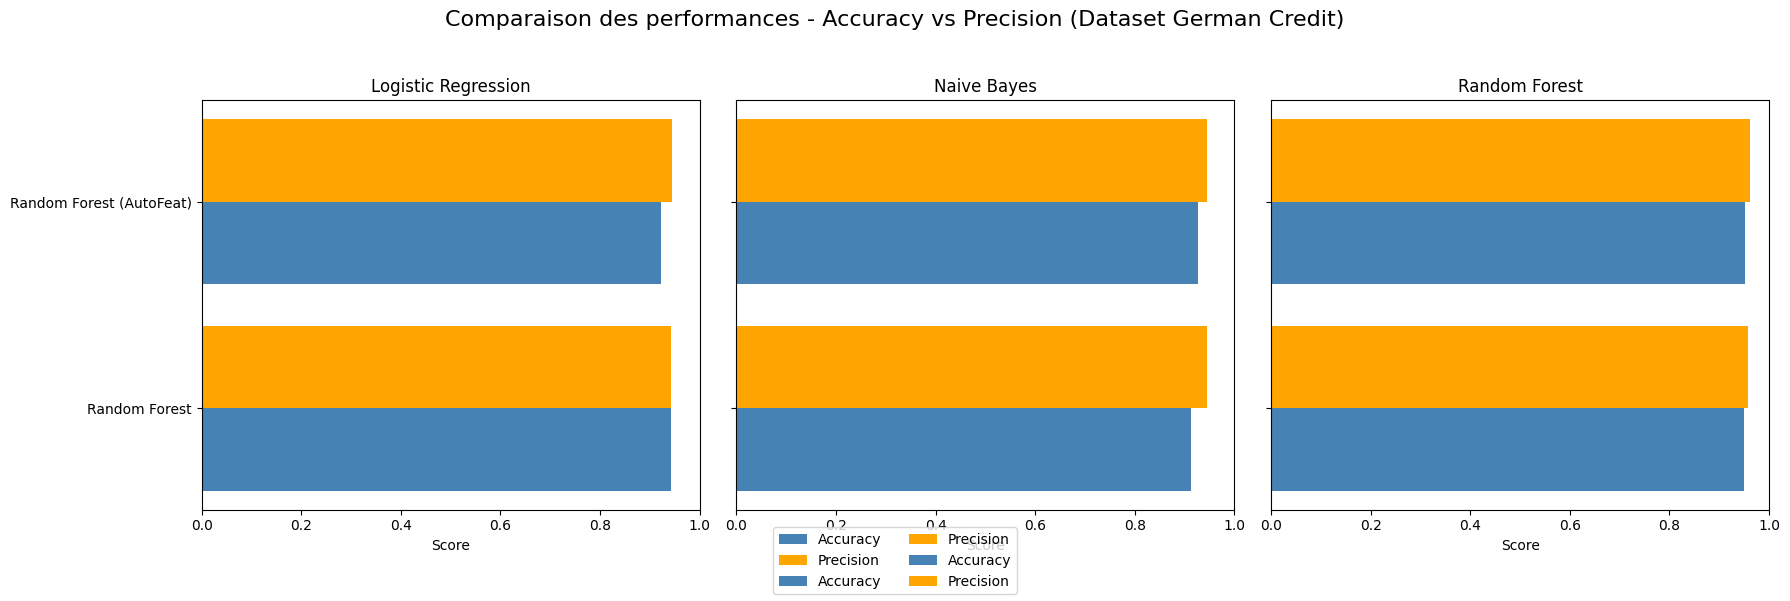

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Organisation des données par modèle
model_groups = {
    "Logistic Regression": {
        "labels": ["Logistic Reg.", "LogReg (AutoFeat)"],
        "accuracy": [logreg_accuracy, acc_logreg_af],
        "precision": [logreg_precision, prec_logreg_af]
    },
    "Naive Bayes": {
        "labels": ["Naive Bayes", "Naive Bayes (AutoFeat)"],
        "accuracy": [nb_accuracy, acc_nb_af],
        "precision": [nb_precision, prec_nb_af]
    },
    "Random Forest": {
        "labels": ["Random Forest", "Random Forest (AutoFeat)"],
        "accuracy": [rf_accuracy, acc_rf_af],
        "precision": [rf_precision, prec_rf_af]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_name, data) in enumerate(model_groups.items()):
    ax = axes[i]
    y = np.arange(len(data["labels"]))
    bar_height = 0.4

    # Accuracy (bleu)
    ax.barh(y - bar_height/2, data["accuracy"], height=bar_height, color='steelblue', label='Accuracy')
    # Precision (orange)
    ax.barh(y + bar_height/2, data["precision"], height=bar_height, color='orange', label='Precision')

    ax.set_yticks(y)
    ax.set_yticklabels(data["labels"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_title(model_name)

fig.suptitle("Comparaison des performances - Accuracy vs Precision (Dataset German Credit)", fontsize=16)
fig.legend(loc="lower center", ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
